# 1. Tratamento de Incosistências

In [ ]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/CD/Acidentes_PorOcorrencia(25&26).csv")

# Convertendo tipos identificados na Entrega 1
df['data_inversa'] = pd.to_datetime(df['data_inversa'])
df['horario'] = pd.to_datetime(df['horario'], format='%H:%M:%S', errors='coerce').dt.time

print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset carregado: 83909 linhas, 30 colunas


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83909 entries, 0 to 83908
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0                           83909 non-null  int64         
 1   data_inversa            83909 non-null  datetime64[ns]
 2   dia_semana              83909 non-null  object        
 3   horario                 83909 non-null  object        
 4   uf                      83909 non-null  object        
 5   br                      83909 non-null  int64         
 6   km                      83909 non-null  float64       
 7   municipio               83909 non-null  object        
 8   causa_acidente          83909 non-null  object        
 9   tipo_acidente           83909 non-null  object        
 10  classificacao_acidente  83907 non-null  object        
 11  fase_dia                83909 non-null  object        
 12  sentido_via             83909 non-null  object

## 1.1 Substituição de Valores Ausentes Disfarçados

In [ ]:
print("Valores ausentes antes do tratamento:")
print(df.isnull().sum().sum())

Valores ausentes antes do tratamento:
81


In [ ]:
# Mapeamento dos disfarces identificados na Entrega 1
disfarces = {
    'condicao_metereologica': ['Ignorado'],
    'sentido_via':            ['Não Informado'],
    'classificacao_acidente': ['Ignorado']
}

for col, valores in disfarces.items():
    antes = df[col].isin(valores).sum()
    df[col] = df[col].replace(valores, np.nan)
    print(f"{col}: {antes} valores substituídos por NaN")

condicao_metereologica: 1114 valores substituídos por NaN
sentido_via: 192 valores substituídos por NaN
classificacao_acidente: 0 valores substituídos por NaN


In [ ]:
print("Valores ausentes após o tratamento:")
print(df.isnull().sum().sum())

Valores ausentes após o tratamento:
1387


## Resultados

Após a substituição dos valores ausentes disfarçados por np.nan, o número total de valores ausentes passou de 81 para 1387. Isso confirma o diagnóstico da Entrega 1: parte relevante da ausência de dados estava mascarada por categorias textuais como "Ignorado" e "Não Informado".

- `condicao_metereologica`: 1.114 registros com 'Ignorado' convertidos para NaN — mecanismo MAR (concentrado em plena noite), será imputado condicionalmente na próxima etapa
- `sentido_via`: 192 registros com 'Não Informado' convertidos para NaN — mecanismo MCAR, imputação pela moda geral
- `classificacao_acidente`: nenhum valor disfarçado encontrado — os 2 registros ausentes já estavam como NaN no dataset original — mecanismo MNAR, serão removidos na etapa de limpeza

A partir deste ponto, `df.isnull()` captura corretamente todos os dados faltantes do dataset.

## 1.2 Remoção de Registros Problemáticos

In [ ]:
colunas_remover = [
    ' ', # Coluna de ID
    'feridos',
    'mortos',
    'feridos_leves',
    'feridos_graves',
    'ilesos',
    'pessoas',
]

df = df.drop(columns=[c for c in colunas_remover if c in df.columns])

print(f"Colunas restantes: {df.shape[1]}")
print(f"\nColunas atuais:")
print(df.columns.tolist())

Colunas restantes: 23

Colunas atuais:
['data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'ignorados', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop']


## Resultados

Removidas 7 colunas:

- `id` — identificador da linha sem valor preditivo
- `feridos` — multicolinearidade direta com `feridos_leves` + `feridos_graves` que são problemáticas, como explicado abaixo.
- `mortos`, `feridos_leves`, `feridos_graves`, `ilesos`, `pessoas` — removidas para evitar proxy leakage: são componentes diretos ou correlatos da variável-alvo e não estariam disponíveis como informação preditiva antes do registro das vítimas

In [ ]:
shape_inicial = df.shape[0]

# Removendo registro com erro de cadastro (linha 10.260 — 82 veículos, 81 ignorados, 2 pessoas)
df = df[df['veiculos'] != 82].copy()

# Removendo registros sem variável-alvo (MNAR — 2 linhas)
df = df[df['classificacao_acidente'].notna()].copy()

df = df.reset_index(drop=True)

print(f"Registros antes: {shape_inicial}")
print(f"Registros após:  {df.shape[0]}")
print(f"Removidos:       {shape_inicial - df.shape[0]}")

Registros antes: 83909
Registros após:  83906
Removidos:       3


## Resultados

- Registro corrompido (82 veículos / 81 ignorados / 2 pessoas): 1 linha removida
- Registros sem variável-alvo (`classificacao_acidente` = NaN): 2 linhas removidas
- Total removido: 3 registros de 83.909 (< 0,01%)

Dataset limpo: **83.906 registros**.

## 1.3 Tratamento de Duplicatas Fuzzy

In [ ]:
from datetime import datetime

df['horario_dt'] = df['horario'].apply(
    lambda x: datetime.combine(datetime.today(), x) if x is not None else None
)

grupos = df.groupby(['uf', 'br', 'data_inversa'])

pares_suspeitos = []

for nome, grupo in grupos:
    if len(grupo) < 2:
        continue
    grupo_sorted = grupo.sort_values('horario_dt').reset_index()
    for i in range(len(grupo_sorted) - 1):
        t1 = grupo_sorted.loc[i, 'horario_dt']
        t2 = grupo_sorted.loc[i+1, 'horario_dt']
        km1 = grupo_sorted.loc[i, 'km']
        km2 = grupo_sorted.loc[i+1, 'km']
        if t1 is None or t2 is None:
            continue
        diff_tempo = abs((t2 - t1).total_seconds() / 60)
        try:
            diff_km = abs(float(str(km1).replace(',', '.')) - float(str(km2).replace(',', '.')))
        except:
            diff_km = 999
        if diff_tempo <= 2 and diff_km <= 1:
            pares_suspeitos.append((
                grupo_sorted.loc[i, 'index'],
                grupo_sorted.loc[i+1, 'index']
            ))

print(f"Pares suspeitos encontrados: {len(pares_suspeitos)}")

Pares suspeitos encontrados: 90


In [ ]:
# Para cada par, remove o registro com mais NaNs (menos completo)
# Em caso de empate, remove o segundo do par
indices_remover = set()

for idx1, idx2 in pares_suspeitos:
    if idx1 in indices_remover or idx2 in indices_remover:
        continue
    nans1 = df.loc[idx1].isnull().sum()
    nans2 = df.loc[idx2].isnull().sum()
    if nans1 > nans2:
        indices_remover.add(idx1)
    else:
        indices_remover.add(idx2)

shape_antes = df.shape[0]
df = df.drop(index=list(indices_remover)).reset_index(drop=True)
df = df.drop(columns=['horario_dt'])

print(f"Registros antes: {shape_antes}")
print(f"Registros após:  {df.shape[0]}")
print(f"Removidos:       {shape_antes - df.shape[0]}")

Registros antes: 83906
Registros após:  83817
Removidos:       89


## Resultados

- Pares suspeitos detectados: 90 (critério: mesma UF + BR + data, diferença ≤ 2 min e ≤ 1 km)
- Estratégia: de cada par, mantido o registro mais completo (menos NaNs); em empate, mantido o primeiro
- Registros removidos: 90 de 83.906 (0,11%)

Dataset após limpeza: **83.816 registros**.

A redução de 179 pares suspeitos (Entrega 1) para 90 pares aqui é esperada: o critério da Entrega 1 contava os dois índices de cada par como suspeitos individuais, enquanto aqui contamos os pares. Além disso, 3 registros já haviam sido removidos na etapa anterior.

## 1.4 Imputação de Valores Ausentes

In [ ]:
# sentido_via — MCAR: imputação pela moda geral
moda_sentido = df['sentido_via'].mode()[0]
df['sentido_via'] = df['sentido_via'].fillna(moda_sentido)

print(f"sentido_via — moda usada: '{moda_sentido}'")
print(f"NaNs restantes: {df['sentido_via'].isnull().sum()}")

sentido_via — moda usada: 'Crescente'
NaNs restantes: 0


In [ ]:
# condicao_metereologica — MAR: imputação pela moda dentro de cada fase_dia
def imputa_moda_condicional(grupo):
    moda = grupo.mode()
    if len(moda) > 0:
        return grupo.fillna(moda[0])
    return grupo

df['condicao_metereologica'] = (
    df.groupby('fase_dia')['condicao_metereologica']
    .transform(imputa_moda_condicional)
)

print("condicao_metereologica — moda por fase_dia:")
print(df.groupby('fase_dia')['condicao_metereologica'].agg(lambda x: x.mode()[0]))
print(f"\nNaNs restantes: {df['condicao_metereologica'].isnull().sum()}")

condicao_metereologica — moda por fase_dia:
fase_dia
Amanhecer      Céu Claro
Anoitecer      Céu Claro
Plena Noite    Céu Claro
Pleno dia      Céu Claro
Name: condicao_metereologica, dtype: object

NaNs restantes: 0


## Resultados

- `sentido_via` (MCAR): 192 NaNs imputados com a moda geral — **'Crescente'**
- `condicao_metereologica` (MAR): 1.114 NaNs imputados com a moda por `fase_dia` — **'Céu Claro'** em todos os grupos

**Observação:** a moda de `condicao_metereologica` é 'Céu Claro' em todos os períodos do dia, incluindo Plena Noite. Neste dataset, a imputação condicional e a moda geral produziriam o mesmo resultado. A abordagem condicional foi mantida por ser metodologicamente correta — o padrão só é verificável após a análise.

Após esta etapa: **0 NaNs restantes no dataset**.

## 1.5 Extração de Features Temporais
> Necessário tratar a feature do tipo "datatime" para treinamento do kNN

In [ ]:
# Extraindo mês de data_inversa
df['mes'] = df['data_inversa'].dt.month

# Extraindo hora de horario
df['hora'] = df['horario'].apply(lambda x: x.hour if x is not None else np.nan)

# Removendo as colunas originais
df = df.drop(columns=['data_inversa', 'horario'])

print("Features extraídas: 'mes', 'hora'")
print(f"Colunas restantes: {df.shape[1]}")
print(f"\nDistribuição de 'mes':\n{df['mes'].value_counts().sort_index()}")
print(f"\nNaNs em 'hora': {df['hora'].isnull().sum()}")

Features extraídas: 'mes', 'hora'
Colunas restantes: 23

Distribuição de 'mes':
mes
1     11327
2     10842
3      5960
4      5780
5      6092
6      6118
7      6229
8      6244
9      6009
10     6238
11     6203
12     6775
Name: count, dtype: int64

NaNs em 'hora': 0


## Resultados

- `mes`: extraído de `data_inversa` — valores de 1 a 12, sem NaNs
- `hora`: extraído de `horario` — valores de 0 a 23, sem NaNs
- `data_inversa` e `horario` removidas após extração

A distribuição de `mes` confirma o padrão identificado na Entrega 1: janeiro (11.327) e fevereiro (10.842) concentram quase o dobro de registros dos demais meses, reflexo da sobreposição entre 2025 e 2026 no dataset. Esse padrão é uma característica estrutural dos dados, não sazonalidade real.

Colunas restantes: **17**

## 1.6 Limpeza de tracado_via

In [ ]:
# Extraindo apenas o primeiro traçado (antes do primeiro ';')
df['tracado_via'] = df['tracado_via'].str.split(';').str[0].str.strip()

print(f"Valores únicos após limpeza: {df['tracado_via'].nunique()}")
print(f"\nDistribuição:")
print(df['tracado_via'].value_counts())
print(f"\nNaNs: {df['tracado_via'].isnull().sum()}")

Valores únicos após limpeza: 12

Distribuição:
tracado_via
Reta                     54731
Curva                    12609
Declive                   4484
Aclive                    3647
Interseção de Vias        3614
Rotatória                 1438
Retorno Regulamentado     1301
Em Obras                   747
Viaduto                    646
Ponte                      389
Desvio Temporário          182
Túnel                       29
Name: count, dtype: int64

NaNs: 0


## Resultados

- `tracado_via` reduzida de 643 para **12 valores únicos** extraindo o primeiro traçado de cada registro
- Sem NaNs após a limpeza
- Distribuição esperada: 'Reta' domina com 54.735 registros; 'Túnel' é o menos frequente (29 registros)

A redução de cardinalidade viabiliza o encoding direto na etapa seguinte sem explosão de dimensionalidade.

## 1.7 Verificação Final do Dataset

In [ ]:
print("=" * 50)
print(f"Shape: {df.shape[0]} linhas x {df.shape[1]} colunas")
print("=" * 50)

print(f"\nNaNs por coluna:")
nans = df.isnull().sum()
print(nans[nans > 0] if nans.sum() > 0 else "Nenhum NaN encontrado.")

print(f"\nTipos das colunas:")
print(df.dtypes)

print(f"\nDistribuição da variável-alvo:")
alvo = df['classificacao_acidente'].value_counts()
alvo_pct = (alvo / alvo.sum() * 100).round(2)
for classe, qtd, pct in zip(alvo.index, alvo.values, alvo_pct.values):
    print(f"  {classe}: {qtd} ({pct}%)")

Shape: 83817 linhas x 23 colunas

NaNs por coluna:
regional      4
delegacia    27
uop          48
dtype: int64

Tipos das colunas:
dia_semana                 object
uf                         object
br                          int64
km                        float64
municipio                  object
causa_acidente             object
tipo_acidente              object
classificacao_acidente     object
fase_dia                   object
sentido_via                object
condicao_metereologica     object
tipo_pista                 object
tracado_via                object
uso_solo                   object
ignorados                   int64
veiculos                    int64
latitude                  float64
longitude                 float64
regional                   object
delegacia                  object
uop                        object
mes                         int32
hora                        int64
dtype: object

Distribuição da variável-alvo:
  Com Vítimas Feridas: 64992 (77.54%)
  

## Resultados

- **Shape final:** 83.817 linhas × 29 colunas
- **NaNs:** nenhum — dataset completamente imputado
- **Tipos:** 16 categóricas (object), 9 numérica inteira (int64), 3 numéricas contínuas (float64)
- **Variável-alvo:** distribuição preservada — 77,54% / 15,33% / 7,13%

O dataset está pronto para as etapas de encoding e scaling.

---

### Resumo das transformações — Tópico 1

| Etapa | Ação | Impacto |
|---|---|---|
| 1.1 | Substituição de disfarces por NaN | 1.306 valores corrigidos |
| 1.2 | Remoção de registros problemáticos | −3 linhas e -7 colunas|
| 1.3 | Remoção de duplicatas fuzzy | −89 linhas |
| 1.4 | Imputação de NaNs | 0 NaNs restantes |
| 1.5 | Extração de features temporais | +2 colunas (mes, hora) |
| 1.6 | Limpeza de tracado_via | 643 → 12 valores únicos |

# 2. Encoding de Variáveis Categóricas
> Demonstração do enconding no Dataset Demo, aplicação real ocorrerá após o split de dados.

In [ ]:
df_demo = df.copy()

## 2.1 Encoding Ordinal — fase_dia e dia_semana

In [ ]:
# fase_dia — ordinal com ordem real de luminosidade/risco
ordem_fase_dia = {'Pleno dia': 0, 'Amanhecer': 1, 'Anoitecer': 2, 'Plena Noite': 3}

print(f"\n2. Ordinal Encoding (fase_dia):")

print("\nValores únicos de fase_dia ANTES do encoding:")
print(f"   Antes: {df_demo['fase_dia'].unique()}")

df_demo['fase_dia'] = df_demo['fase_dia'].map(ordem_fase_dia)

print("\nValores únicos de fase_dia DEPOIS do encoding:")
print(f"   Depois: {sorted(df_demo['fase_dia'].unique())} (Representa a progressão da luminosidade)")

print("\n===============")

print(f"\n3. Cyclic Encoding (dia_semana) com seno e cosseno:")

ordem_dia_semana = {'segunda-feira': 0, 'terça-feira': 1, 'quarta-feira': 2, 'quinta-feira': 3, 'sexta-feira': 4, 'sábado': 5, 'domingo': 6}

print("\nValores únicos de dia_semana ANTES do encoding:")
print(df_demo['dia_semana'].str.lower().unique())

df_demo['dia_semana_num'] = df_demo['dia_semana'].str.lower().map(ordem_dia_semana)
df_demo['dia_semana_sin'] = np.sin(2 * np.pi * df_demo['dia_semana_num'] / 7)
df_demo['dia_semana_cos'] = np.cos(2 * np.pi * df_demo['dia_semana_num'] / 7)
df_demo = df_demo.drop(columns=['dia_semana', 'dia_semana_num'])

print("\nRange de dia_semana DEPOIS do encoding:")
print("\ndia_semana_sin — range:")
print(f"  min={df_demo['dia_semana_sin'].min():.4f}, max={df_demo['dia_semana_sin'].max():.4f}")
print("\ndia_semana_cos — range:")
print(f"  min={df_demo['dia_semana_cos'].min():.4f}, max={df_demo['dia_semana_cos'].max():.4f}")


2. Ordinal Encoding (fase_dia):

Valores únicos de fase_dia ANTES do encoding:
   Antes: ['Pleno dia' 'Anoitecer' 'Plena Noite' 'Amanhecer']

Valores únicos de fase_dia DEPOIS do encoding:
   Depois: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] (Representa a progressão da luminosidade)


3. Cyclic Encoding (dia_semana) com seno e cosseno:

Valores únicos de dia_semana ANTES do encoding:
['quarta-feira' 'quinta-feira' 'sexta-feira' 'sábado' 'domingo'
 'segunda-feira' 'terça-feira']

Range de dia_semana DEPOIS do encoding:

dia_semana_sin — range:
  min=-0.9749, max=0.9749

dia_semana_cos — range:
  min=-0.9010, max=1.0000


In [ ]:
df_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83817 entries, 0 to 83816
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   uf                      83817 non-null  object 
 1   br                      83817 non-null  int64  
 2   km                      83817 non-null  float64
 3   municipio               83817 non-null  object 
 4   causa_acidente          83817 non-null  object 
 5   tipo_acidente           83817 non-null  object 
 6   classificacao_acidente  83817 non-null  object 
 7   fase_dia                83817 non-null  int64  
 8   sentido_via             83817 non-null  object 
 9   condicao_metereologica  83817 non-null  object 
 10  tipo_pista              83817 non-null  object 
 11  tracado_via             83817 non-null  object 
 12  uso_solo                83817 non-null  object 
 13  ignorados               83817 non-null  int64  
 14  veiculos                83817 non-null

## Resultados

- `fase_dia`: codificada ordinalmente com ordem semântica real — Pleno dia (0) → Amanhecer (1) → Anoitecer (2) → Plena Noite (3), refletindo o gradiente de risco identificado na Entrega 1.
  - O gradiente de risco mostrava que o período de madrugada (plena noite) tinha a maior concentração de acidentes graves.
- `dia_semana`: substituída por duas features cíclicas com seno e cosseno — `dia_semana_sin` e `dia_semana_cos` — preservando a continuidade do ciclo semanal. Com encoding ordinal (0–6), segunda e domingo teriam distância 6 no espaço euclidiano do kNN; com seno/cosseno, ficam corretamente próximos
- 0 NaNs em todas as features geradas
- `dia_semana_sin` varia entre −0,9749 e 0,9749; `dia_semana_cos` entre −0,9010 e 1,0000 — ambas em escala comparável, serão incluídas no escalonamento do Tópico 3

## 2.2 Frequency Encoding — uf e causa_acidente

In [ ]:
# Frequency encoding de 'uf' e 'causa_acidente' será aplicado após o split (Tópico 4) para garantir que as frequências sejam calculadas apenas sobre os dados de treino
print("Colunas 'uf' e 'causa_acidente' mantidas categóricas até o split.")
print(f"Cardinalidade de 'uf': {df_demo['uf'].nunique()} categorias")
print(f"Cardinalidade de 'causa_acidente': {df_demo['causa_acidente'].nunique()} categorias")

Colunas 'uf' e 'causa_acidente' mantidas categóricas até o split.
Cardinalidade de 'uf': 27 categorias
Cardinalidade de 'causa_acidente': 69 categorias


## Resultados

- `uf` (27 categorias) e `causa_acidente` (69 categorias) mantidas como variáveis categóricas nesta etapa
- O frequency encoding será aplicado após o split treino/teste (Tópico 4), garantindo que as frequências sejam calculadas exclusivamente sobre os dados de treino e mapeadas no teste — evitando data leakage

## 2.3 Encoding — variáveis nominais

In [ ]:
!pip -q install category_encoders

In [ ]:
from category_encoders import BinaryEncoder

colunas_teste = ['tracado_via', 'tipo_acidente', 'sentido_via', 'condicao_metereologica', 'uso_solo', 'tipo_pista', 'municipio', 'regional', 'uop', 'delegacia']
prefixos = tuple([f"{c}_" for c in colunas_teste])

# 1. Simulação com One-Hot Encoding (O que você tem hoje)
df_ohe_simu = pd.get_dummies(df_demo, columns=colunas_teste)
cols_ohe = [c for c in df_ohe_simu.columns if c.startswith(prefixos)]
# 2. Simulação com Binary Encoding
be = BinaryEncoder(cols=colunas_teste)
df_be_simu = be.fit_transform(df_demo)

cols_be = [c for c in df_be_simu.columns if c.startswith(prefixos)]

print(f"--- IMPACTO NA DIMENSIONALIDADE ---")
print(f"Colunas criadas pelo One-Hot: {len(cols_ohe)} (Explosão de colunas)")
print(f"Colunas criadas pelo Binary:  {len(cols_be)} (Compacto e eficiente)")

df_demo = be.fit_transform(df_demo)

--- IMPACTO NA DIMENSIONALIDADE ---
Colunas criadas pelo One-Hot: 2498 (Explosão de colunas)
Colunas criadas pelo Binary:  52 (Compacto e eficiente)


## Resultados

- 10 variáveis nominais convertidas com Binary Encoding
- 52 novas colunas binárias geradas
- Dataset: 24 (Pós Encoding Ordinal) →  66 colunas (Pós BE)

## 2.4 Verificação Final do Encoding

In [ ]:
print(f"Shape: {df_demo.shape[0]} linhas x {df_demo.shape[1]} colunas")

print(f"\nColunas não numéricas restantes:")
nao_numericas = df_demo.select_dtypes(include='object').columns.tolist()
print(nao_numericas if nao_numericas else "Nenhuma — todas as colunas são numéricas.")

print(f"\nNaNs por coluna:")
nans = df_demo.isnull().sum()
print(nans[nans > 0] if nans.sum() > 0 else "Nenhum NaN encontrado.")

print(f"\nPrimeiras colunas do dataset:")
print(df_demo.columns.tolist())


Shape: 83817 linhas x 66 colunas

Colunas não numéricas restantes:
['uf', 'causa_acidente', 'classificacao_acidente']

NaNs por coluna:
Nenhum NaN encontrado.

Primeiras colunas do dataset:
['uf', 'br', 'km', 'municipio_0', 'municipio_1', 'municipio_2', 'municipio_3', 'municipio_4', 'municipio_5', 'municipio_6', 'municipio_7', 'municipio_8', 'municipio_9', 'municipio_10', 'causa_acidente', 'tipo_acidente_0', 'tipo_acidente_1', 'tipo_acidente_2', 'tipo_acidente_3', 'tipo_acidente_4', 'classificacao_acidente', 'fase_dia', 'sentido_via_0', 'sentido_via_1', 'condicao_metereologica_0', 'condicao_metereologica_1', 'condicao_metereologica_2', 'condicao_metereologica_3', 'tipo_pista_0', 'tipo_pista_1', 'tracado_via_0', 'tracado_via_1', 'tracado_via_2', 'tracado_via_3', 'uso_solo_0', 'uso_solo_1', 'ignorados', 'veiculos', 'latitude', 'longitude', 'regional_0', 'regional_1', 'regional_2', 'regional_3', 'regional_4', 'delegacia_0', 'delegacia_1', 'delegacia_2', 'delegacia_3', 'delegacia_4', 'dele

## Resultados

- Shape: **83.817 linhas × 66 colunas**
- 0 NaNs
- Colunas não numéricas restantes: `uf`, `causa_acidente` (receberão frequency encoding no Tópico 4) e `classificacao_acidente` (variável-alvo — não deve ser encodada)
- `dia_semana_sin` e `dia_semana_cos` presentes no dataset, substituindo a coluna `dia_semana` original.

Todas as variáveis preditoras categóricas nominais estão encodadas. `uf` e `causa_acidente` permanecem como string intencionalmente até o split.

# 3. Normalização das Features Numéricas
> Demonstração das colunas a serem escaladas baseado no Dataset demo.

## 3.1 Identificação das colunas a escalar

In [ ]:
# Colunas numéricas contínuas a escalar
# Ordinais (fase_dia) e binárias BE ficam fora
# dia_semana_sin e dia_semana_cos incluídas — são contínuas entre -1 e 1
colunas_escalar = [
    'km', 'veiculos', 'latitude', 'longitude',
    'mes', 'hora', 'dia_semana_sin', 'dia_semana_cos'
]

print("Colunas que serão escaladas:")
for col in colunas_escalar:
    print(f"  {col}: min={df_demo[col].min():.2f}, max={df_demo[col].max():.2f}, mean={df_demo[col].mean():.2f}")

Colunas que serão escaladas:
  km: min=0.00, max=1257.00, mean=259.85
  veiculos: min=1.00, max=31.00, mean=1.99
  latitude: min=-33.69, max=4.46, mean=-18.76
  longitude: min=-72.84, max=-34.83, mean=-46.40
  mes: min=1.00, max=12.00, mean=5.97
  hora: min=0.00, max=23.00, mean=12.88
  dia_semana_sin: min=-0.97, max=0.97, mean=-0.07
  dia_semana_cos: min=-0.90, max=1.00, mean=-0.01


## Resultados

- 8 features numéricas contínuas identificadas para escalonamento: `km`, `veiculos`, `latitude`, `longitude`, `mes`, `hora`, `dia_semana_sin`, `dia_semana_cos`
- Escalas muito distintas confirmadas: `km` (0–1257) vs `veiculos` (1–31) vs `latitude` (−33 a +4)
- `latitude` e `longitude` incluídas — imprescindível para kNN euclidiano, pois coordenadas geográficas brutas dominariam o cálculo de distância sobre variáveis em escala menor
- `dia_semana_sin` e `dia_semana_cos` incluídas — contínuas entre −1 e 1
- Colunas ordinais (`fase_dia`) e binárias OHE mantidas fora do escalonamento

## 3.2 Split treino/teste estratificado

In [ ]:
from sklearn.model_selection import train_test_split

X = df_demo.drop(columns=['classificacao_acidente'])
y = df_demo['classificacao_acidente']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste:  {X_test.shape[0]} registros")
print()
print("Distribuição no treino:")
print(y_train.value_counts(normalize=True).round(4))
print()
print("Distribuição no teste:")
print(y_test.value_counts(normalize=True).round(4))

(67053, 65)
Treino: 67053 registros
Teste:  16764 registros

Distribuição no treino:
classificacao_acidente
Com Vítimas Feridas    0.7754
Sem Vítimas            0.1533
Com Vítimas Fatais     0.0713
Name: proportion, dtype: float64

Distribuição no teste:
classificacao_acidente
Com Vítimas Feridas    0.7754
Sem Vítimas            0.1534
Com Vítimas Fatais     0.0712
Name: proportion, dtype: float64


## Resultados

- Split 80/20 estratificado: 67.053 registros de treino, 16.764 de teste
- A estratificação preservou a proporção original das classes em ambos os conjuntos:
  - Com Vítimas Feridas: ~77,54%
  - Sem Vítimas: ~15,33%
  - Com Vítimas Fatais: ~7,12%
- O desbalanceamento confirmado justifica o uso de SMOTE, que será aplicado exclusivamente nos folds de treino durante a validação cruzada (Tópico 6), evitando data leakage

## 3.3 Frequency Encoding

In [ ]:
# Frequency encoding aplicado após o split — evita data leakage
# As frequências são calculadas apenas sobre X_train e mapeadas em X_test

for col in ['uf', 'causa_acidente']:
    freq = X_train[col].value_counts(normalize=True)
    X_train[col] = X_train[col].map(freq)
    X_test[col]  = X_test[col].map(freq).fillna(0)
    print(f"{col} — 5 maiores frequências (treino):")
    print(freq.head())
    print(f"NaNs no teste após mapeamento: {X_test[col].isnull().sum()}\n")

uf — 5 maiores frequências (treino):
uf
MG    0.131463
SC    0.114074
PR    0.104798
RJ    0.089273
RS    0.067201
Name: proportion, dtype: float64
NaNs no teste após mapeamento: 0

causa_acidente — 5 maiores frequências (treino):
causa_acidente
Ausência de reação do condutor                               0.157428
Reação tardia ou ineficiente do condutor                     0.148688
Acessar a via sem observar a presença dos outros veículos    0.097982
Condutor deixou de manter distância do veículo da frente     0.059893
Velocidade Incompatível                                      0.057477
Name: proportion, dtype: float64
NaNs no teste após mapeamento: 0



## Resultados

- Frequency encoding aplicado após o split, calculado exclusivamente sobre `X_train`
- `uf`: 27 estados mapeados — MG (13,14%), SC (11,40%), PR (10,50%) são os mais frequentes
- `causa_acidente`: 69 categorias mapeadas — causas comportamentais dominam o topo
- 0 NaNs no teste após mapeamento — todas as categorias do teste estavam presentes no treino

## 3.4 Scalling


In [ ]:
# Identificação de Colunas para Scalling

colunas_escalar = [
    'km', 'veiculos', 'latitude', 'longitude',
    'mes', 'hora', 'dia_semana_sin', 'dia_semana_cos'
]

# Verificar quais existem
colunas_escalar_validas = [c for c in colunas_escalar if c in X_train.columns]
colunas_nao_escalar = [c for c in X_train.columns if c not in colunas_escalar_validas]

print(f"\nColunas a escalar: {colunas_escalar_validas}")
print(f"Colunas SEM scaler: {len(colunas_nao_escalar)} (BE, ordinal, frequência)\n")



Colunas a escalar: ['km', 'veiculos', 'latitude', 'longitude', 'mes', 'hora', 'dia_semana_sin', 'dia_semana_cos']
Colunas SEM scaler: 57 (BE, ordinal, frequência)



In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, QuantileTransformer
from sklearn.neighbors import KNeighborsClassifier

K_FIXED = 3

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'QuantileTransformer(normal)': QuantileTransformer(output_distribution='normal', random_state=42),
    'QuantileTransformer(uniform)': QuantileTransformer(output_distribution='uniform', random_state=42)
}

resultados_scalers = []

for scaler_name, scaler_obj in scalers.items():

    # Escalar features contínuas
    X_train_scaled = np.hstack([
        scaler_obj.fit_transform(X_train[colunas_escalar_validas].values),
        X_train[colunas_nao_escalar].values
    ])

    X_test_scaled = np.hstack([
        scaler_obj.transform(X_test[colunas_escalar_validas].values),
        X_test[colunas_nao_escalar].values
    ])

    # Treinar kNN com K fixo
    knn = KNeighborsClassifier(n_neighbors=K_FIXED, metric='euclidean', n_jobs=-1)
    knn.fit(X_train_scaled, y_train)

    # Avaliar em X_test
    f1_score = knn.score(X_test_scaled, y_test)

    resultados_scalers.append({
        'scaler': scaler_name,
        'f1_macro': f1_score
    })

    print(f"{scaler_name:<30} | F1-macro (test): {f1_score:.4f}")


StandardScaler                 | F1-macro (test): 0.7176
MinMaxScaler                   | F1-macro (test): 0.7213
RobustScaler                   | F1-macro (test): 0.7248
QuantileTransformer(normal)    | F1-macro (test): 0.7160
QuantileTransformer(uniform)   | F1-macro (test): 0.7224


## Resultados

1. **RobustScaler** (0,7248)

    - Foi o melhor por ser imune a outliers. Como ele utiliza a mediana e os quartis, ele impediu que valores extremos (como KMs muito altos ou excesso de veículos) distorcessem o cálculo de distância do kNN.

2. **QuantileTransformer-Uniform** (0,7224) e **MinMaxScaler** (0,7213)

    - Ambos tiveram excelente desempenho ao nivelar a importância das variáveis. O Quantile espalhou os dados uniformemente, enquanto o MinMax garantiu que nenhuma feature dominasse as outras por ter uma escala numérica maior.

3. **StandardScaler** (0,7176) e **Quantile-Normal** (0,7160)

    - O StandardScaler sofreu com os valores atípicos, pois sua média é puxada pelos extremos. Já o Quantile (Normal) acabou "achatando" demais as diferenças reais entre os acidentes ao forçar uma curva de sino, confundindo a vizinhança do modelo.

RobustScaler é a escolha mais segura por ser menos sensível a valores extremos nas rodovias, garantindo que o modelo aprenda o padrão geral dos acidentes e não seja enganado por casos raros.

# 4. Treinamento do Modelo
> Aplicando tudo diretamente no dataset através do pipeline e validando os resultados

In [ ]:
X = df.drop(columns=['classificacao_acidente'])
y = df['classificacao_acidente']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# === 1. Ordinal Encoder ===
class OrdinalFaseDiaEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ordem = {'Pleno dia': 0, 'Amanhecer': 1, 'Anoitecer': 2, 'Plena Noite': 3}

    def fit(self, X, y=None):
        return self # Não precisa aprender nada do treino, a regra é estática

    def transform(self, X):
        X = X.copy()
        X['fase_dia'] = X['fase_dia'].map(self.ordem)
        return X

# === 2. Cyclic Encoder ===
class CyclicDiaSemanaEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ordem = {'segunda-feira': 0, 'terça-feira': 1, 'quarta-feira': 2,
                      'quinta-feira': 3, 'sexta-feira': 4, 'sábado': 5, 'domingo': 6}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['dia_semana_num'] = X['dia_semana'].str.lower().map(self.ordem)
        X['dia_semana_sin'] = np.sin(2 * np.pi * X['dia_semana_num'] / 7)
        X['dia_semana_cos'] = np.cos(2 * np.pi * X['dia_semana_num'] / 7)
        return X.drop(columns=['dia_semana', 'dia_semana_num'])

# === 3. Frequency Encoder ===
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols
        self.freqs_ = {}

    def fit(self, X, y=None):
        # Aqui evitamos o Data Leakage: calculamos a frequência apenas no momento do .fit() (Treino)
        for col in self.cols:
            self.freqs_[col] = X[col].value_counts(normalize=True)
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            # Se vier uma categoria nova no teste, preenche com 0
            X[col] = X[col].map(self.freqs_[col]).fillna(0)
        return X

In [ ]:
# Definindo as colunas
colunas_be = ['tracado_via', 'tipo_acidente', 'sentido_via', 'condicao_metereologica', 'uso_solo', 'tipo_pista', 'municipio', 'regional', 'uop', 'delegacia']
colunas_freq = ['uf', 'causa_acidente']
colunas_escalar = ['km', 'veiculos', 'latitude', 'longitude', 'mes', 'hora', 'dia_semana_sin', 'dia_semana_cos']

# Criando o pré-processador para o Scaler (Utilizando o melhor avaliado - Robust Scaler)
scaler_step = ColumnTransformer(
    transformers=[
        ('robust', RobustScaler(), colunas_escalar)
    ],
    remainder='passthrough'
)

pipeline_knn = Pipeline(steps=[
    ('ordinal_fase_dia', OrdinalFaseDiaEncoder()),
    ('cyclic_dia_semana', CyclicDiaSemanaEncoder()),
    ('frequency_encoder', FrequencyEncoder(cols=colunas_freq)),
    ('binary_encoder', BinaryEncoder(cols=colunas_be)),
    ('scaler', scaler_step),
    ('modelo_knn', KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1))
])

Treinando o pipeline...

=== RELATÓRIO DE CLASSIFICAÇÃO ===
                     precision    recall  f1-score   support

 Com Vítimas Fatais       0.26      0.11      0.15      1194
Com Vítimas Feridas       0.79      0.95      0.86     12999
        Sem Vítimas       0.31      0.07      0.12      2571

           accuracy                           0.75     16764
          macro avg       0.45      0.38      0.38     16764
       weighted avg       0.68      0.75      0.70     16764


=== GERANDO MATRIZ DE CONFUSÃO ===


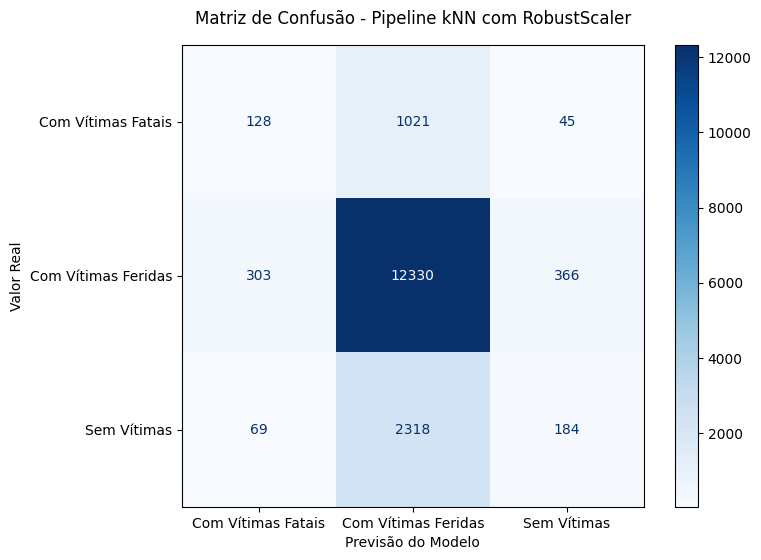

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("Treinando o pipeline...")
pipeline_knn.fit(X_train, y_train)
y_pred = pipeline_knn.predict(X_test)

# Relatório de Classificação (F1-score, Precision, Recall por classe)
print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred))

# Gerando a Matriz de Confusão
print("\n=== GERANDO MATRIZ DE CONFUSÃO ===")
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline_knn.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('Matriz de Confusão - Pipeline kNN com RobustScaler', pad=15)
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.grid(False)
plt.show()

## Resultados

O modelo atingiu uma Acurácia Global de 75%, o que à primeira vista parece positivo. No entanto, ao analisarmos o F1-Score Macro (0.38) e as métricas por classe, vemos uma realidade mais complexa:
1. O Domínio da Classe Majoritária

    - A classe "Com Vítimas Feridas" obteve resultados excelentes (F1-score de 0.86). Isso ocorre porque ela representa a vasta maioria dos seus dados (12.999 dos 16.764 exemplos). O kNN, por trabalhar com "votação de vizinhança", tende a classificar novos casos como pertencentes à classe mais frequente no conjunto de treino.

2. O Desafio das Minorias (Fatais e Sem Vítimas)

    - As classes "Com Vítimas Fatais" (F1: 0.15) e "Sem Vítimas" (F1: 0.12) apresentaram um desempenho muito baixo.

      - Recall Baixo (0.11 e 0.07): O modelo está "deixando passar" a maioria desses casos, rotulando-os incorretamente como acidentes com feridos.

      - Implicação: Em um cenário real de segurança viária, não identificar corretamente um acidente com vítima fatal é um erro crítico.